In [34]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from eda_package.data import DataManager
from eda_package.features import FeatureEngineer
from eda_package.preprocessor import PreprocessorManager
from eda_package.model import ModelManager
!pip install shap
import shap

In [35]:
# Load project components

data_manager = DataManager()
feature_engineer = FeatureEngineer()
preprocessor_manager = PreprocessorManager()
model_manager = ModelManager()

preprocessor_manager.load()
model_manager.load()

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=10,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Recreate model input pipeline
X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

X_train_fe = feature_engineer.engineer_features(X_train.copy())
X_test_fe = feature_engineer.engineer_features(X_test.copy())

X_train_processed = preprocessor_manager.transform(X_train_fe)
X_test_processed = preprocessor_manager.transform(X_test_fe)

In [ ]:
# Feature names
feature_names = preprocessor_manager.preprocessor.get_feature_names_out()
feature_names[:10]

array(['num__lead_time', 'num__arrival_date_year',
       'num__arrival_date_week_number', 'num__arrival_date_day_of_month',
       'num__stays_in_weekend_nights', 'num__stays_in_week_nights',
       'num__adults', 'num__children', 'num__babies',
       'num__previous_cancellations'], dtype=object)

In [36]:
# Convert processed matrices to DataFrames for readable SHAP plots
try:
    X_train_shap = pd.DataFrame.sparse.from_spmatrix(
        X_train_processed,
        columns=feature_names,
        index=X_train.index
    )
    X_test_shap = pd.DataFrame.sparse.from_spmatrix(
        X_test_processed,
        columns=feature_names,
        index=X_test.index
    )
except Exception:
    X_train_shap = pd.DataFrame(
        X_train_processed,
        columns=feature_names,
        index=X_train.index
    )
    X_test_shap = pd.DataFrame(
        X_test_processed,
        columns=feature_names,
        index=X_test.index
    )

In [37]:
# Small background sample
background = X_train_shap.sample(min(200, len(X_train_shap)), random_state=42)

In [44]:
# Direct SHAP implementation
f = lambda X: model_manager.model.predict_proba(X)[:, 1]

background = X_train_shap.iloc[:100]
X_explain = X_test_shap.iloc[:50]

explainer = shap.Explainer(f, background)
shap_values = explainer(X_explain)

In [45]:
# Explain a subset first & compute SHAP values
X_explain = X_test_shap.iloc[:200]
shap_values = explainer(X_explain)

PermutationExplainer explainer: 201it [00:11,  2.38it/s]                         


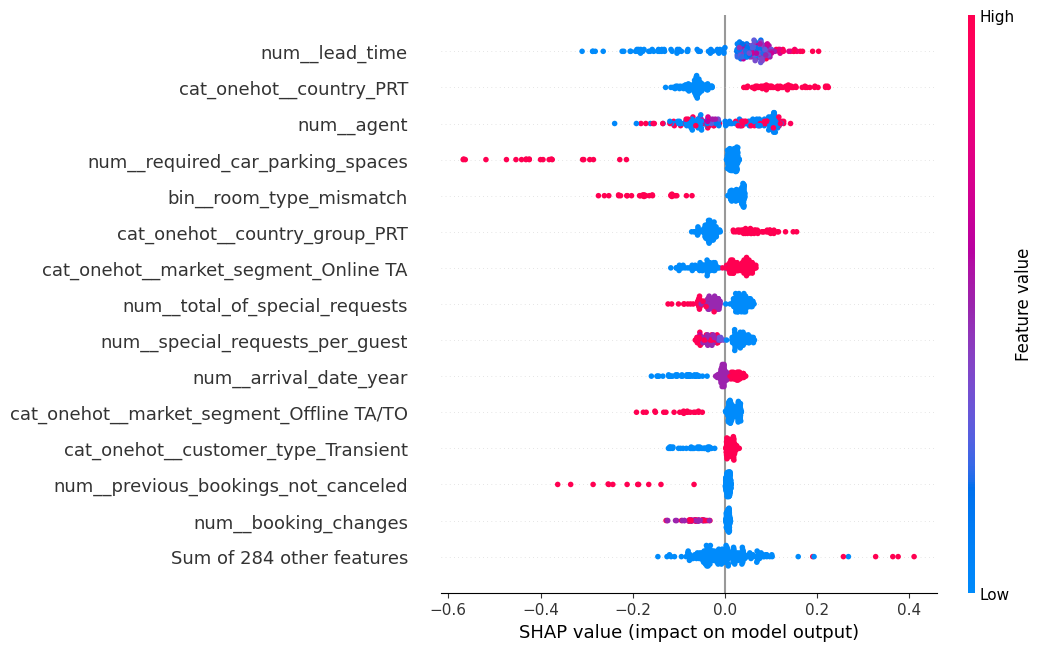

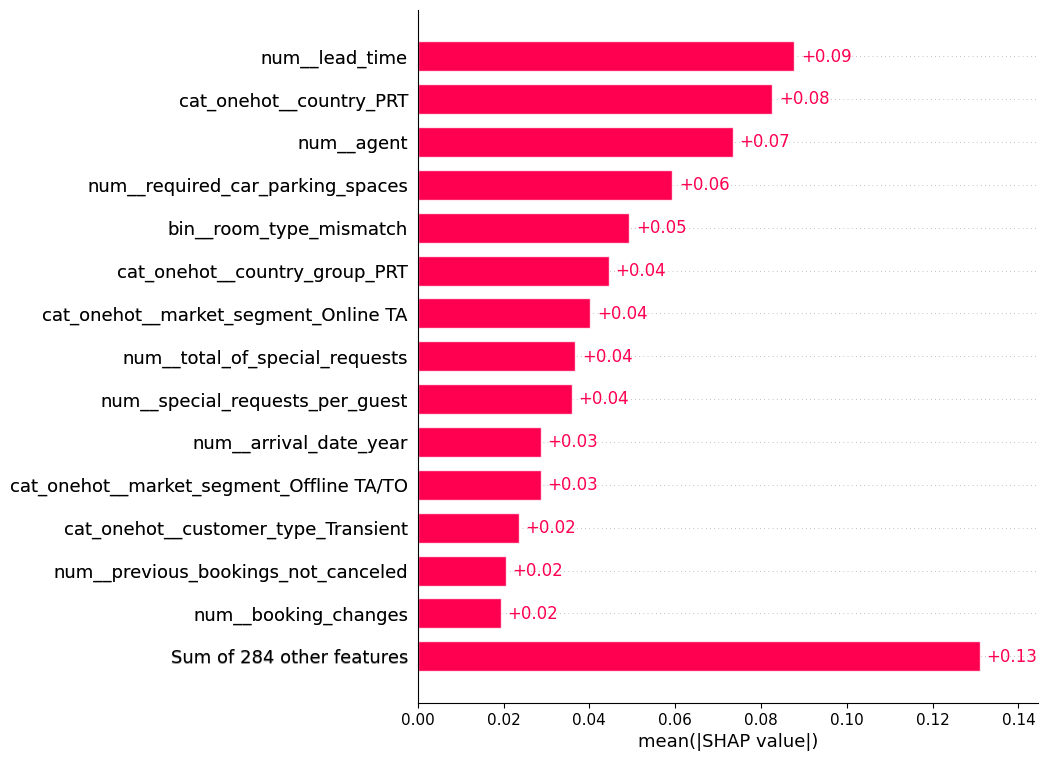

In [46]:
# Global plots
shap.plots.beeswarm(shap_values, max_display=15)
shap.plots.bar(shap_values, max_display=15)

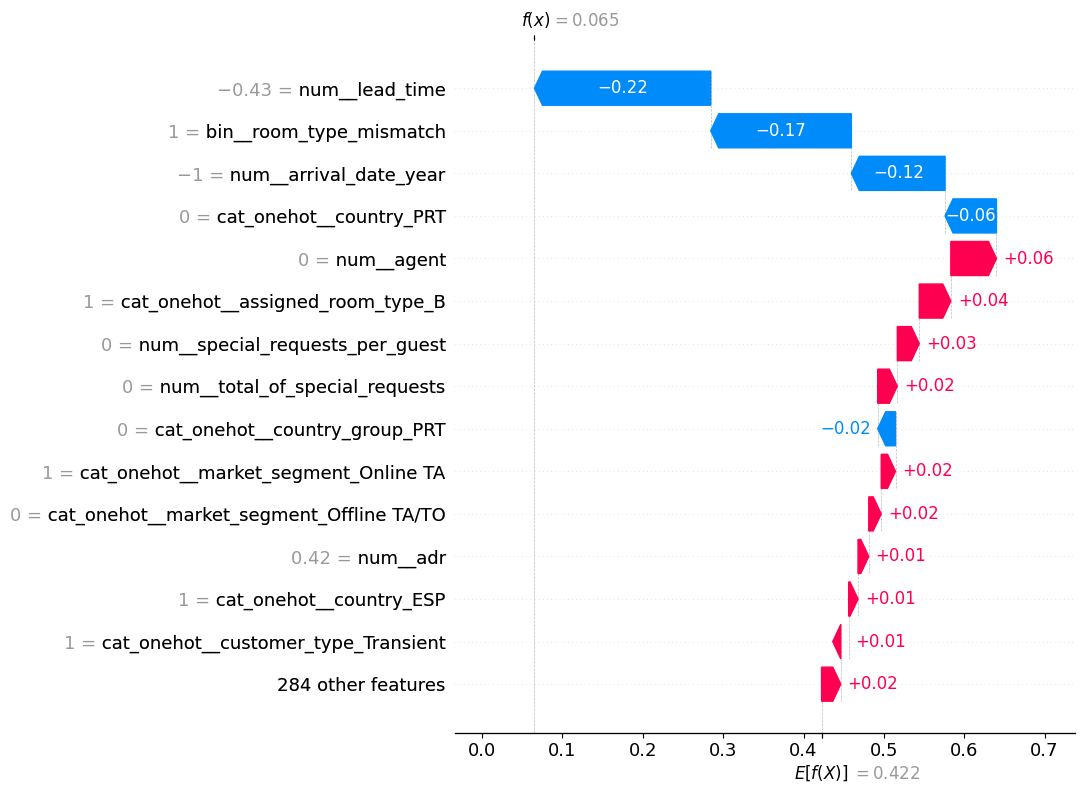

In [47]:
# Local plots
shap.plots.waterfall(shap_values[0], max_display=15)

In [52]:
def clean_feature_name(name: str) -> str:
    for prefix in ["cat__", "num__", "ord__", "remainder__"]:
        name = name.replace(prefix, "")
    return name

In [ ]:
# features that stay whole i.e. lead_time of special_request, and features that are groupes like country_PRT -> country

def group_feature_name(name: str) -> str:
    # remove pipeline prefixes
    for prefix in ["cat_onehot__", "cat__", "num__", "ord__", "bin__", "remainder__"]:
        if name.startswith(prefix):
            name = name[len(prefix):]

    # exact engineered / numeric features to keep as-is
    keep_exact = {
        "lead_time",
        "arrival_date_year",
        "arrival_date_week_number",
        "arrival_date_day_of_month",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "babies",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "booking_changes",
        "days_in_waiting_list",
        "adr",
        "required_car_parking_spaces",
        "total_of_special_requests",
        "special_requests_per_guest",
        "room_type_mismatch",
        "total_nights",
        "agent",
        "company",
        "is_repeated_guest",
    }

    if name in keep_exact:
        return name

    # collapse known one-hot encoded families
    grouped_prefixes = [
        "hotel_",
        "meal_",
        "country_",
        "country_group_",
        "market_segment_",
        "distribution_channel_",
        "reserved_room_type_",
        "assigned_room_type_",
        "deposit_type_",
        "customer_type_",
        "arrival_date_month_",
    ]

    for prefix in grouped_prefixes:
        if name.startswith(prefix):
            if prefix == "country_group_":
                return "country"
            return prefix[:-1]

    # fallback: leave name unchanged
    return name

In [54]:
import pandas as pd

def grouped_local_shap(shap_row, feature_names):
    df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_row.values,
        "feature_value": shap_row.data
    })

    df["feature_group"] = df["feature"].apply(group_feature_name)

    grouped = (
        df.groupby("feature_group", as_index=False)["shap_value"]
        .sum()
    )

    grouped["abs_shap"] = grouped["shap_value"].abs()
    grouped = grouped.sort_values("abs_shap", ascending=False).drop(columns="abs_shap")

    return grouped

In [59]:
grouped_exp = grouped_local_shap(shap_values[0], X_explain.columns)
grouped_exp.head(10)

,feature_group,shap_value
20,lead_time,-0.219322
26,room_type_mismatch,-0.174995
5,arrival_date_year,-0.116594
13,country,-0.057553
2,agent,0.056805
6,assigned_room_type,0.040936
21,market_segment,0.033185
27,special_requests_per_guest,0.027319
30,total_of_special_requests,0.024432
0,adr,0.013355


In [66]:
# Groupes Local Shap for one booking

import pandas as pd
import numpy as np


def grouped_local_shap(shap_row, feature_names):
    """
    Aggregate one local SHAP explanation from transformed features
    back to business-friendly feature groups.
    """
    # robust extraction
    values = np.array(shap_row.values)
    data = np.array(shap_row.data)

    df = pd.DataFrame({
        "feature": list(feature_names),
        "feature_value": data,
        "shap_value": values
    })

    df["feature_group"] = df["feature"].apply(group_feature_name)

    grouped = (
        df.groupby("feature_group", as_index=False)
          .agg({"shap_value": "sum"})
    )

    grouped["abs_shap"] = grouped["shap_value"].abs()
    grouped = grouped.sort_values("abs_shap", ascending=False).drop(columns="abs_shap")

    return grouped

# test
grouped_exp = grouped_local_shap(shap_values[0], X_explain.columns)
grouped_exp.head(10)

,feature_group,shap_value
20,lead_time,-0.219322
26,room_type_mismatch,-0.174995
5,arrival_date_year,-0.116594
13,country,-0.057553
2,agent,0.056805
6,assigned_room_type,0.040936
21,market_segment,0.033185
27,special_requests_per_guest,0.027319
30,total_of_special_requests,0.024432
0,adr,0.013355


In [67]:
# Grouped global Shap across many bookings

def grouped_global_shap(shap_values, feature_names):
    """
    Aggregate global SHAP importance by business-friendly feature groups.
    Uses mean absolute SHAP across all explained rows.
    """
    shap_matrix = np.array(shap_values.values)

    shap_df = pd.DataFrame(shap_matrix, columns=list(feature_names))
    mean_abs = shap_df.abs().mean(axis=0).reset_index()
    mean_abs.columns = ["feature", "mean_abs_shap"]

    mean_abs["feature_group"] = mean_abs["feature"].apply(group_feature_name)

    grouped = (
        mean_abs.groupby("feature_group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )

    return grouped

# test
grouped_global = grouped_global_shap(shap_values, X_explain.columns)
grouped_global.head(15)

,feature_group,mean_abs_shap
13,country,0.164780
20,lead_time,0.087733
2,agent,0.073434
21,market_segment,0.070384
24,required_car_parking_spaces,0.059324
26,room_type_mismatch,0.049325
30,total_of_special_requests,0.036705
14,customer_type,0.036460
27,special_requests_per_guest,0.035924
5,arrival_date_year,0.028712


In [68]:
def split_local_drivers(grouped_df, top_n=5):
    positive = (
        grouped_df[grouped_df["shap_value"] > 0]
        .sort_values("shap_value", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    negative = (
        grouped_df[grouped_df["shap_value"] < 0]
        .sort_values("shap_value", ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )

    return positive, negative

In [69]:
pos_drivers, neg_drivers = split_local_drivers(grouped_exp, top_n=5)

print("Positive drivers")
display(pos_drivers)

print("Negative drivers")
display(neg_drivers)

Positive drivers


,feature_group,shap_value
0,agent,0.056805
1,assigned_room_type,0.040936
2,market_segment,0.033185
3,special_requests_per_guest,0.027319
4,total_of_special_requests,0.024432


Negative drivers


,feature_group,shap_value
0,lead_time,-0.219322
1,room_type_mismatch,-0.174995
2,arrival_date_year,-0.116594
3,country,-0.057553
4,deposit_type,-0.009820


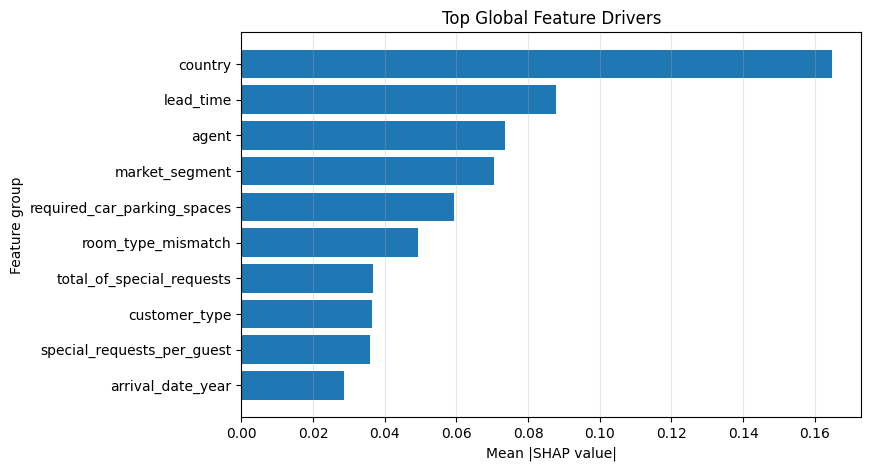

In [70]:
import matplotlib.pyplot as plt

top_global = grouped_global.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_global["feature_group"][::-1], top_global["mean_abs_shap"][::-1])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature group")
plt.title("Top Global Feature Drivers")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [72]:
grouped_exp = grouped_local_shap(shap_values[0], X_explain.columns)
grouped_exp.head(10)

,feature_group,shap_value
20,lead_time,-0.219322
26,room_type_mismatch,-0.174995
5,arrival_date_year,-0.116594
13,country,-0.057553
2,agent,0.056805
6,assigned_room_type,0.040936
21,market_segment,0.033185
27,special_requests_per_guest,0.027319
30,total_of_special_requests,0.024432
0,adr,0.013355


In [73]:
grouped_global = grouped_global_shap(shap_values, X_explain.columns)
grouped_global.head(15)

,feature_group,mean_abs_shap
13,country,0.164780
20,lead_time,0.087733
2,agent,0.073434
21,market_segment,0.070384
24,required_car_parking_spaces,0.059324
26,room_type_mismatch,0.049325
30,total_of_special_requests,0.036705
14,customer_type,0.036460
27,special_requests_per_guest,0.035924
5,arrival_date_year,0.028712


In [74]:
pos_drivers, neg_drivers = split_local_drivers(grouped_exp, top_n=5)
display(pos_drivers)
display(neg_drivers)

,feature_group,shap_value
0,agent,0.056805
1,assigned_room_type,0.040936
2,market_segment,0.033185
3,special_requests_per_guest,0.027319
4,total_of_special_requests,0.024432


,feature_group,shap_value
0,lead_time,-0.219322
1,room_type_mismatch,-0.174995
2,arrival_date_year,-0.116594
3,country,-0.057553
4,deposit_type,-0.009820


In [ ]:
pos_drivers, neg_drivers = split_local_drivers(grouped_exp, top_n=5)
display(pos_drivers)
display(neg_drivers)

,feature_group,shap_value
0,agent,0.056805
1,assigned_room_type,0.040936
2,market_segment,0.033185
3,special_requests_per_guest,0.027319
4,total_of_special_requests,0.024432


,feature_group,shap_value
0,lead_time,-0.219322
1,room_type_mismatch,-0.174995
2,arrival_date_year,-0.116594
3,country,-0.057553
4,deposit_type,-0.009820


In [78]:
DISPLAY_NAMES = {
    "adr": "Average daily rate",
    "lead_time": "Lead time",
    "assigned_room_type": "Assigned room type",
    "reserved_room_type": "Reserved room type",
    "room_type_mismatch": "Room type mismatch",
    "market_segment": "Market segment",
    "customer_type": "Customer type",
    "country": "Country",
    "deposit_type": "Deposit type",
    "agent": "Travel agent",
    "required_car_parking_spaces": "Parking spaces requested",
    "previous_bookings_not_canceled": "Previous completed bookings",
    "previous_cancellations": "Previous cancellations",
    "total_of_special_requests": "Total special requests",
    "special_requests_per_guest": "Special requests per guest",
    "arrival_date_year": "Arrival year",
    "booking_changes": "Booking changes",
    "stays_in_week_nights": "Week nights",
    "stays_in_weekend_nights": "Weekend nights",
}

In [79]:
grouped_exp["display_name"] = grouped_exp["feature_group"].map(DISPLAY_NAMES).fillna(grouped_exp["feature_group"])
grouped_global["display_name"] = grouped_global["feature_group"].map(DISPLAY_NAMES).fillna(grouped_global["feature_group"])

In [82]:
grouped_global.head(15)

,feature_group,mean_abs_shap,display_name
13,country,0.164780,Country
20,lead_time,0.087733,Lead time
2,agent,0.073434,Travel agent
21,market_segment,0.070384,Market segment
24,required_car_parking_spaces,0.059324,Parking spaces requested
26,room_type_mismatch,0.049325,Room type mismatch
30,total_of_special_requests,0.036705,Total special requests
14,customer_type,0.036460,Customer type
27,special_requests_per_guest,0.035924,Special requests per guest
5,arrival_date_year,0.028712,Arrival year


In [84]:
grouped_global.head(50)

,feature_group,mean_abs_shap,display_name
13,country,0.164780,Country
20,lead_time,0.087733,Lead time
2,agent,0.073434,Travel agent
21,market_segment,0.070384,Market segment
24,required_car_parking_spaces,0.059324,Parking spaces requested
26,room_type_mismatch,0.049325,Room type mismatch
30,total_of_special_requests,0.036705,Total special requests
14,customer_type,0.036460,Customer type
27,special_requests_per_guest,0.035924,Special requests per guest
5,arrival_date_year,0.028712,Arrival year


In [86]:
#rebuild raw test data
X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

#create a real date column for filtering
X_test_with_date = X_test.copy()

X_test_with_date["arrival_date"] = pd.to_datetime(
    X_test_with_date["arrival_date_year"].astype(str)
    + "-"
    + X_test_with_date["arrival_date_month"].astype(str)
    + "-"
    + X_test_with_date["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

In [87]:
X_test_with_date[["arrival_date_year", "arrival_date_month", "arrival_date_day_of_month", "arrival_date"]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
41000,2015,August,10,2015-08-10
27416,2016,August,27,2016-08-27
30610,2016,December,12,2016-12-12
38792,2017,July,23,2017-07-23
7532,2016,August,13,2016-08-13


In [88]:
selected_date = pd.Timestamp("2017-07-15")

In [89]:
X_test_date = X_test_with_date[X_test_with_date["arrival_date"] == selected_date].copy()

In [90]:
print(X_test_date.shape)

(50, 33)


In [91]:
X_test_date_fe = feature_engineer.engineer_features(X_test_date.copy())
X_test_date_processed = preprocessor_manager.transform(X_test_date_fe)

In [99]:
feature_names = preprocessor_manager.preprocessor.get_feature_names_out()

try:
    X_train_shap = pd.DataFrame.sparse.from_spmatrix(
        X_train_processed,
        columns=feature_names,
        index=X_train.index
    )
    X_test_shap = pd.DataFrame.sparse.from_spmatrix(
        X_test_processed,
        columns=feature_names,
        index=X_test.index
    )
except Exception:
    X_train_shap = pd.DataFrame(
        X_train_processed,
        columns=feature_names,
        index=X_train.index
    )
    X_test_shap = pd.DataFrame(
        X_test_processed,
        columns=feature_names,
        index=X_test.index
    )

In [100]:
f = lambda X: model_manager.model.predict_proba(X)[:, 1]

background = X_train_shap.iloc[:50]
explainer = shap.Explainer(f, background)

In [101]:
X_test_date_fe = feature_engineer.engineer_features(X_test_date.copy())
X_test_date_processed = preprocessor_manager.transform(X_test_date_fe)

try:
    X_test_date_shap = pd.DataFrame.sparse.from_spmatrix(
        X_test_date_processed,
        columns=feature_names,
        index=X_test_date.index
    )
except Exception:
    X_test_date_shap = pd.DataFrame(
        X_test_date_processed,
        columns=feature_names,
        index=X_test_date.index
    )

shap_values_date = explainer(X_test_date_shap)
grouped_global_date = grouped_global_shap(shap_values_date, X_test_date_shap.columns)
grouped_global_date.head(15)

,feature_group,mean_abs_shap
13,country,0.168962
20,lead_time,0.091231
2,agent,0.087746
21,market_segment,0.074695
30,total_of_special_requests,0.045363
27,special_requests_per_guest,0.042922
14,customer_type,0.035708
24,required_car_parking_spaces,0.034426
5,arrival_date_year,0.028217
26,room_type_mismatch,0.024419


In [102]:
result = global_shap_for_date(
    selected_date="2017-07-15",
    X_raw=X_test,
    feature_engineer=feature_engineer,
    preprocessor_manager=preprocessor_manager,
    explainer=explainer,
    grouped_global_shap_fn=grouped_global_shap,
    min_rows=5,
)

display(result["grouped_global_shap"].head(15))

NameError: name 'global_shap_for_date' is not defined

In [ ]:
pos_drivers, neg_drivers = split_local_drivers(grouped_exp, top_n=5)
display(pos_drivers)
display(neg_drivers)

,feature_group,shap_value
0,agent,0.056805
1,assigned_room_type,0.040936
2,market_segment,0.033185
3,special_requests_per_guest,0.027319
4,total_of_special_requests,0.024432


,feature_group,shap_value
0,lead_time,-0.219322
1,room_type_mismatch,-0.174995
2,arrival_date_year,-0.116594
3,country,-0.057553
4,deposit_type,-0.009820
